### Dome motors temperature - SITCOM-2015
    * https://rubinobs.atlassian.net/browse/SITCOM-2015

**Description**

We want to analyze the main dome’s motor temperature during the dome Endurance test. These results needs to be compares it with the temperatures measured with the infrared camera.

### Notebook Setup

In [1]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

# Load the CSV data, skipping the first two lines
file_path = 'data/20250327_07_29_08_endurance_test.csv'
data = pd.read_csv(file_path)

# List of columns to plot (excluding the first column "TIME")
columns_to_plot = data.columns[1:]
array_time = data['time']
#print(columns_to_plot)
#data.head()
#array_time.head()


### Helper Functions

In [2]:
def time_base(array):
    """
    Subtract the first element of the array from all elements.

    Parameters:
    array: numpy array - the array from which to subtract the first element.

    Returns:
    numpy array - new array with the first element subtracted.
    """
    if len(array) == 0:
        return array  # Return the empty array if no elements
    
    first_element = array[0]  # Get the first element
    result = array - first_element  # Subtract the first element from the whole array
    return result


def plot_columns(data, columns):
    """
    Plots the selected columns against time.

    Parameters:
    data: DataFrame - the DataFrame that contains the data, must include a 'time' column.
    columns: list - list of names of columns to plot.

    Returns:
    None
    """
    plt.figure(figsize=(10, 6))
    plotted = False  # Variable para verificar si se ha graficado algo
    global_min = float('inf')
    global_max = float('-inf')
    min_time = None
    max_time = None

    for column in columns:
        if column in data.columns:
            plt.plot(data['new_time'], data[column], label=column, linewidth=1.0)
            plotted = True

            # Get min and max values for the column
            min_value = data[column].min()
            max_value = data[column].max()
            min_time_col = data.loc[data[column].idxmin(), 'new_time']
            max_time_col = data.loc[data[column].idxmax(), 'new_time']

            # Update global min and max
            if min_value < global_min:
                global_min = min_value
                min_time = min_time_col
            if max_value > global_max:
                global_max = max_value
                max_time = max_time_col

    # Plot the global min and max
    if min_time is not None:
        plt.axhline(y=global_min, color='saddlebrown', linestyle='--', label='Global Min')
        plt.scatter(min_time, global_min, color='saddlebrown', zorder=5)  # Red point for global min
        
    # Plot a vertical line for the global max
    if max_time is not None:
        plt.axhline(y=global_max, color='saddlebrown', linestyle='--', label='Global Max')
        plt.scatter(max_time, global_max, color='saddlebrown', zorder=5)  # Red point for global max    
        
    if plotted:
        plt.title('Selected Dome Temperature Motors against TIME')
        plt.xlabel('TIME [seconds]')
        plt.ylabel('Temp [°C]')

        # Ajustar el número de marcadores en el eje Y
        ax = plt.gca()  # Obtiene el objeto del eje actual
        ax.yaxis.set_major_locator(MaxNLocator(integer=True, prune='both', nbins=25))  # Ajusta según necesites

        plt.legend()
        plt.grid()
        plt.show()

        # Save the plot
        #plt.savefig('DomeTempMotor.png')  # You can also use 'plot.jpg' or other formats
        #plt.close()  # Close the plot to free memory
        
    else:
        print("No valid data to plot for the selected columns.")

### Data Analysis

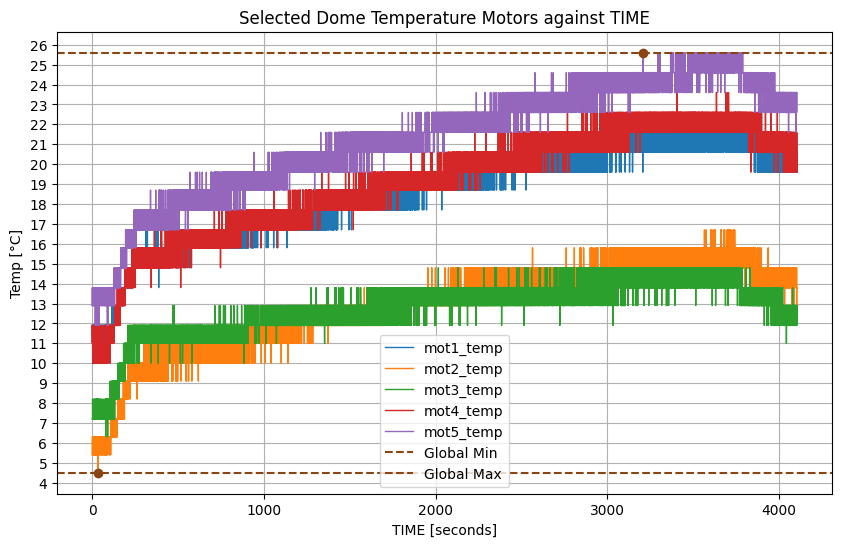

In [3]:
#Subtract the first element 
time_base = time_base(array_time)

# Change of the original DataFrame
data['new_time'] = time_base

# Display the updated DataFrame
#data.head()

#Plots the Temp. motors columns against time.
plot_columns(data, ['mot1_temp', 'mot2_temp', 'mot3_temp', 'mot4_temp', 'mot5_temp'])

In [9]:
#Time spend
# Get the last time value in seconds
t_value = data['new_time'].iloc[-1]  
# Convert seconds to hours
t_hours = t_value  / 3600  
print(t_hours.round(2), "hours - test time spend")

1.14 hours - test time spend


In [8]:
# Obtener estadísticas 
selected_columns = data[['mot1_temp', 'mot2_temp', 'mot3_temp', 'mot4_temp', 'mot5_temp']]
selected_columns.describe().round(2)

,mot1_temp,mot2_temp,mot3_temp,mot4_temp,mot5_temp
count,40779.00,40779.00,40779.00,40779.00,40779.00
mean,18.59,12.93,12.79,19.12,21.42
std,2.36,2.21,1.37,2.73,2.82
min,11.00,4.50,6.30,10.00,11.90
25%,16.70,11.90,11.90,17.70,19.60
50%,19.60,13.80,12.90,19.60,21.60
75%,20.60,14.80,13.80,21.60,23.60
max,22.60,16.70,14.80,23.60,25.60


#### Comment 
* We have data for 5 motor temperatures, and its time, the test period was aprox. 1.14h. Within this period, Motors #2 and #3 have the lowest temperatures, while the remaining motors #1, #4, and #5 have a higher average temperature.

* Trend: Throughout the analyzed period, the temperatures exhibit an upward trend of the motors, suggesting a gradual warming of the motors, with a maximum value reached of 25.6°C of Motor #5 and a minimum of 11.9°C.

* The standard deviation of the temperatures indicates moderate variability of motor temperatures ~ 2.3°C. --> ((2.36 + 2.21 + 1.37 + 2.73 + 2.82 = 11.49)/5 = 2.3).

* Looking at the IR images provided by David S., It is observed temperatures fluctuations at different positions near the dome motor, fluctuation are: 6-7°C, 15-07°C, 8-15°C, 8-13°C, 7-16°C, 9-21°C, 9-23°C, and 10-23°C. Comparing this data to the data from the endurance test, the temperatures fluctuation are in agreement.
